#### Titanic Survival Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, KBinsDiscretizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

### Data Preprocessing

In [2]:
df = pd.read_csv("..\\data\\raw\\train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [5]:
df['Age'].isnull().sum()

np.int64(177)

<Axes: xlabel='Age', ylabel='Count'>

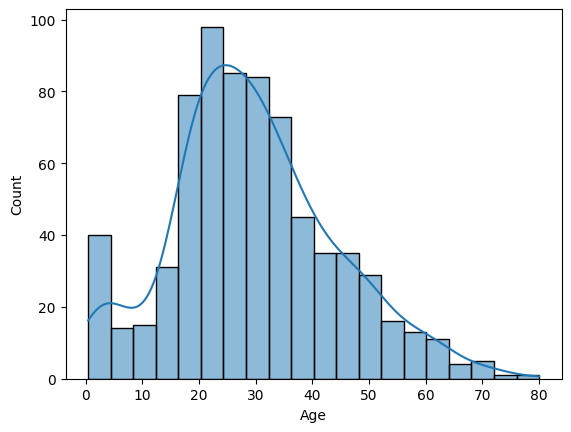

In [6]:
sns.histplot(df['Age'], kde=True)

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [8]:
df['Age'].isna().sum()

np.int64(0)

<Axes: xlabel='Age', ylabel='Count'>

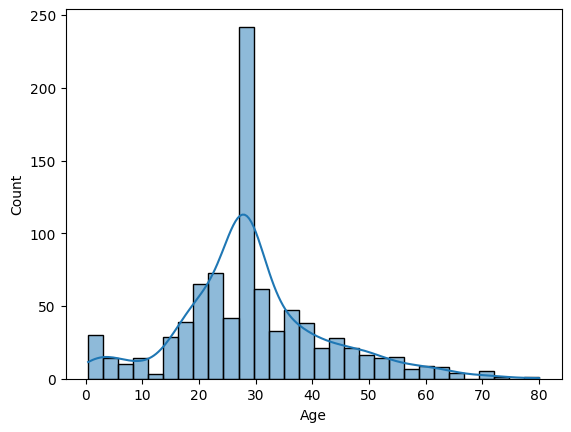

In [9]:
sns.histplot(df['Age'], kde=True)

In [10]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
# Calculate the percentage of missing values in the 'Cabin' column

(df['Cabin'].isna().sum() / len(df)) * 100

np.float64(77.10437710437711)

In [12]:
# Dropping the cabin column as it has more than 77% missing values

df = df.drop('Cabin', axis=1)

In [13]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [14]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [15]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [16]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

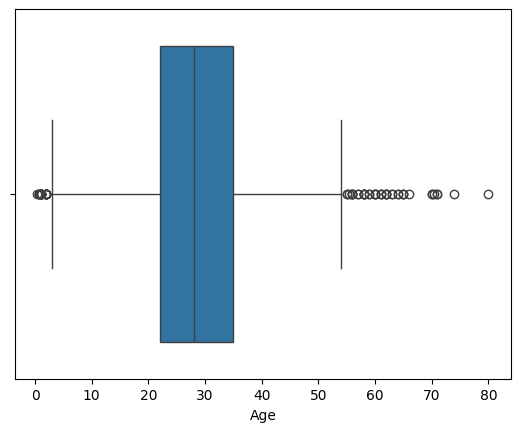

In [17]:
sns.boxplot(x=df['Age'])
plt.show()

In [18]:
z_scores = np.abs(stats.zscore(df['Age']))

In [19]:
(z_scores > 3).sum()

np.int64(7)

In [20]:
outliers = df['Age'][z_scores > 3]

In [21]:
outliers

96     71.0
116    70.5
493    71.0
630    80.0
672    70.0
745    70.0
851    74.0
Name: Age, dtype: float64

In [22]:
# I did not remove the outliers as they are not extreme and they are not affecting the model performance. 
# I will keep them in the dataset.

In [23]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [24]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [25]:
df['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [26]:
df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

<Axes: xlabel='Fare', ylabel='Count'>

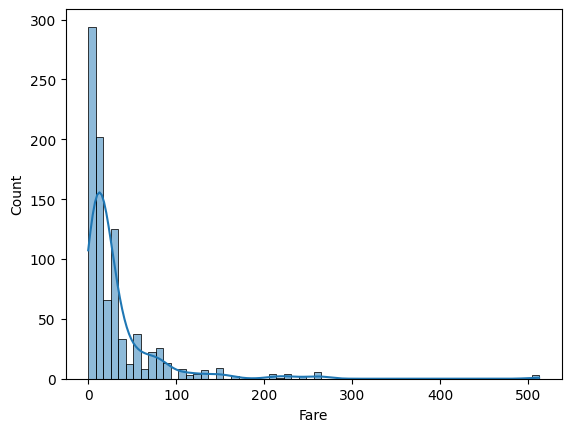

In [27]:
sns.histplot(df['Fare'], kde=True)

In [28]:
(df['Fare'] == 0).sum()

np.int64(15)

In [29]:

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [30]:
# Extracting the title from the name column and creating a new column for it

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\mypci\AppData\Local\Temp\ipykernel_6616\2032609928.py:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [31]:
df.drop('Name', axis=1, inplace=True)

In [32]:
df['Title'].unique()

<StringArray>
[      'Mr',      'Mrs',     'Miss',   'Master',      'Don',      'Rev',
       'Dr',      'Mme',       'Ms',    'Major',     'Lady',      'Sir',
     'Mlle',      'Col',     'Capt', 'Countess', 'Jonkheer']
Length: 17, dtype: str

In [33]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,female,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,male,35.0,0,0,373450,8.0500,S,Mr


In [34]:
# Encoding the categorical variables using label encoding

le_sex = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])

In [35]:
df['Sex'].unique()

array([1, 0])

In [36]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,1,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,0,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,0,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,1,35.0,0,0,373450,8.0500,S,Mr


In [37]:
df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [38]:
# Encoding the 'Embarked' column using one-hot encoding

ohe = OneHotEncoder(sparse_output=False)

In [39]:
encoded_embarked = ohe.fit_transform(df[['Embarked']])

In [40]:
encoded_df = pd.DataFrame(encoded_embarked, columns=ohe.get_feature_names_out(['Embarked']))

In [41]:
# DROPPED ORIGINAL AND EMBEDDED ONE HOT EMBARKED COLUMNS
df = pd.concat([df.drop('Embarked', axis=1), encoded_df], axis=1)

In [42]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,1,0,A/5 21171,7.2500,Mr,0.0,0.0,1.0
1,2,1,1,0,38.0,1,0,PC 17599,71.2833,Mrs,1.0,0.0,0.0
2,3,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,Miss,0.0,0.0,1.0
3,4,1,1,0,35.0,1,0,113803,53.1000,Mrs,0.0,0.0,1.0
4,5,0,3,1,35.0,0,0,373450,8.0500,Mr,0.0,0.0,1.0


In [43]:
df['Pclass'].unique()

array([3, 1, 2])

In [44]:
# I will not discretize the age column as it is not necessary for this dataset 
# and it may lead to loss of information.

# age_discretizer = KBinsDiscretizer(n_bins=4, encode='ordinal')
# df['Age'] = age_discretizer.fit_transform(df[['Age']])

In [45]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,22.0,1,0,A/5 21171,7.2500,Mr,0.0,0.0,1.0
1,2,1,1,0,38.0,1,0,PC 17599,71.2833,Mrs,1.0,0.0,0.0
2,3,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,Miss,0.0,0.0,1.0
3,4,1,1,0,35.0,1,0,113803,53.1000,Mrs,0.0,0.0,1.0
4,5,0,3,1,35.0,0,0,373450,8.0500,Mr,0.0,0.0,1.0


In [46]:
# Applying log transformation to the 'Fare' column to reduce the skewness

df['Fare'] = np.log1p(df['Fare'])

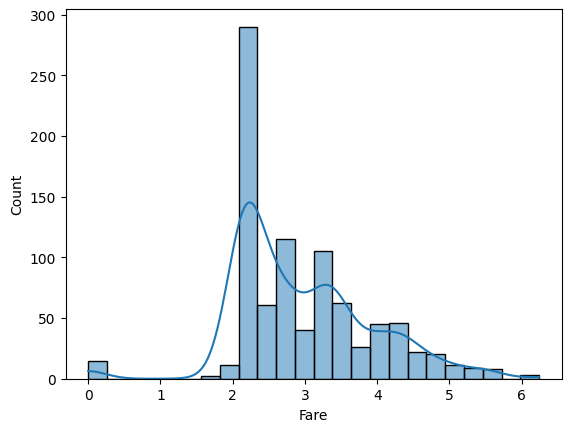

In [47]:
sns.histplot(df['Fare'], kde=True)
plt.show()

In [48]:
# Scaling the numerical features using standard scaler

scaler = StandardScaler()

In [49]:
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

In [50]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,-0.565736,1,0,A/5 21171,-0.879741,Mr,0.0,0.0,1.0
1,2,1,1,0,0.663861,1,0,PC 17599,1.361220,Mrs,1.0,0.0,0.0
2,3,1,3,0,-0.258337,0,0,STON/O2. 3101282,-0.798540,Miss,0.0,0.0,1.0
3,4,1,1,0,0.433312,1,0,113803,1.062038,Mrs,0.0,0.0,1.0
4,5,0,3,1,0.433312,0,0,373450,-0.784179,Mr,0.0,0.0,1.0


In [51]:
# After standard scaling, the values of 'Fare' column are now in the range of -3 to 3.
# Values greater than 3 are considered as outliers.

df[df['Fare'] > 3].value_counts().sum()

np.int64(3)

In [52]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Title,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,1,-0.565736,1,0,A/5 21171,-0.879741,Mr,0.0,0.0,1.0
1,2,1,1,0,0.663861,1,0,PC 17599,1.361220,Mrs,1.0,0.0,0.0
2,3,1,3,0,-0.258337,0,0,STON/O2. 3101282,-0.798540,Miss,0.0,0.0,1.0
3,4,1,1,0,0.433312,1,0,113803,1.062038,Mrs,0.0,0.0,1.0
4,5,0,3,1,0.433312,0,0,373450,-0.784179,Mr,0.0,0.0,1.0


In [53]:
print(df['Ticket'].dtype)

str


In [54]:
df = df.drop(columns=['Ticket'])

In [55]:
# Creating a new feature 'FamilySize' by combining 'SibSp' and 'Parch' columns

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

In [56]:
df = df.drop(columns=['SibSp'])
df = df.drop(columns=['Parch'])

In [57]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Title,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,1,0,3,1,-0.565736,-0.879741,Mr,0.0,0.0,1.0,2
1,2,1,1,0,0.663861,1.361220,Mrs,1.0,0.0,0.0,2
2,3,1,3,0,-0.258337,-0.798540,Miss,0.0,0.0,1.0,1
3,4,1,1,0,0.433312,1.062038,Mrs,0.0,0.0,1.0,2
4,5,0,3,1,0.433312,-0.784179,Mr,0.0,0.0,1.0,1


In [58]:
df['Title'].nunique()

17

In [59]:
title_mapping = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Rev': 'Rev'
}

# Map titles, everything else becomes 'Other'
df['Title'] = df['Title'].map(lambda x: title_mapping.get(x, 'Other'))

In [60]:
df['Title'].unique()

<StringArray>
['Mr', 'Mrs', 'Miss', 'Other', 'Rev']
Length: 5, dtype: str

In [61]:
# Encoding the 'Title' column using label encoding

le_title = LabelEncoder()
df['Title'] = le_title.fit_transform(df['Title'])

In [62]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Title,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,1,0,3,1,-0.565736,-0.879741,1,0.0,0.0,1.0,2
1,2,1,1,0,0.663861,1.361220,2,1.0,0.0,0.0,2
2,3,1,3,0,-0.258337,-0.798540,0,0.0,0.0,1.0,1
3,4,1,1,0,0.433312,1.062038,2,0.0,0.0,1.0,2
4,5,0,3,1,0.433312,-0.784179,1,0.0,0.0,1.0,1


In [63]:
# Data is now preprocessed and ready for model training.

In [64]:
df.to_csv(r"../data/processed/train_processed.csv", index=False)

### Model Training and Evaluation

In [65]:
X = df.drop(columns='Survived')
y = df['Survived']

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# This is just to check the performance of the model on the validation set.

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

accuracy_score(y_val, y_pred)

0.7877094972067039

In [67]:
# Now that we have checked the performance of the model on the validation set, 
# we can fit the model on the entire dataset.

model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [68]:
df = pd.read_csv("../data/raw/test.csv")

In [69]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [70]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [71]:
df = df.drop('Cabin', axis=1)

In [72]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [73]:
z_scores = np.abs(stats.zscore(df['Age']))
outliers = df['Age'][z_scores > 3]

In [74]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)

In [75]:
df.drop('Name', axis=1, inplace=True)

In [76]:
df['Sex'] = le_sex.transform(df['Sex'])

In [77]:
encoded_embarked = ohe.transform(df[['Embarked']])
encoded_df = pd.DataFrame(encoded_embarked, columns=ohe.get_feature_names_out(['Embarked']))

In [78]:
# DROPPED ORIGINAL AND EMBEDDED ONE HOT EMBARKED COLUMNS
df = pd.concat([df.drop('Embarked', axis=1), encoded_df], axis=1)

In [79]:
df['Fare'] = np.log1p(df['Fare'])

In [80]:
df[['Age', 'Fare']] = scaler.transform(df[['Age', 'Fare']])

In [81]:
df = df.drop(columns=['Ticket'])

In [82]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

df = df.drop(columns=['SibSp'])
df = df.drop(columns=['Parch'])

In [83]:
title_mapping = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Rev': 'Rev'
}

# Map titles, everything else becomes 'Other'
df['Title'] = df['Title'].map(lambda x: title_mapping.get(x, 'Other'))

In [84]:
df['Title'] = le_title.transform(df['Title'])

In [85]:
df.head()

,PassengerId,Pclass,Sex,Age,Fare,Title,Embarked_C,Embarked_Q,Embarked_S,FamilySize
0,892,3,1,0.394887,-0.809683,1,0.0,1.0,0.0,1
1,893,3,0,1.355510,-0.911513,2,0.0,0.0,1.0,2
2,894,2,1,2.508257,-0.612461,1,0.0,1.0,0.0,1
3,895,3,1,-0.181487,-0.716562,1,0.0,0.0,1.0,1
4,896,3,0,-0.565736,-0.387631,2,0.0,0.0,1.0,3


In [86]:
predictions = model.predict(df)

In [87]:
submission = pd.DataFrame({
    "PassengerId": df["PassengerId"],
    "Survived": predictions
})

submission.to_csv(r"../data/submission.csv", index=False)

In [89]:
import pickle
pickle.dump(model, open("../models/logisticRegressionModel.pkl", "wb"))